# ``utils.jl``

Test Summary:           | Pass  Total  Time
get_periodic_difference |    3      3  0.0s
Test Summary: | Pass  Total  Time
wrap_position |    3      3  0.0s
Test Summary:         | Pass  Total  Time
random_initial_config |    5      5  0.9s


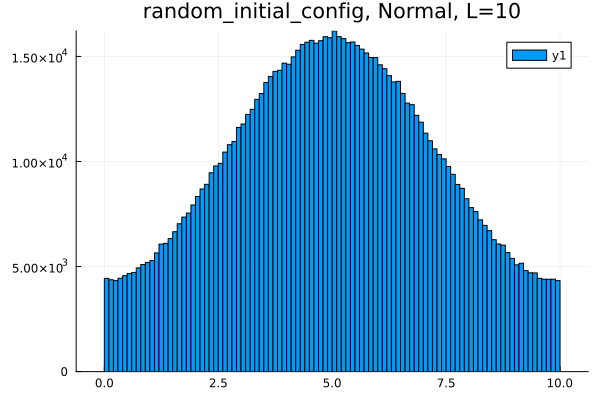

In [38]:
include(joinpath(@__DIR__, "..", "src", "utils.jl"))
using Test

@testset "get_periodic_difference" begin
    @test get_periodic_difference(1.0, 9.0, 10.0) == 2.0
    @test get_periodic_difference(2.0, 3.0, 10.0) == -1.0
    @test get_periodic_difference(1.0, 9.0, 10.0) ==
         -get_periodic_difference(9.0, 1.0, 10.0)        
end

@testset "wrap_position" begin
    @test wrap_position(1.0, 10.0) == 1.0
    @test wrap_position(11.0, 10.0) == 1.0
    @test wrap_position(-1.0, 10.0) == 9.0
end

@testset "random_initial_config" begin
    x, y = random_initial_config(50, 10.0, "Uniform")
    @test length(x) == 50 && length(y) == 50
    @test all(0.0 .<= x .< 10.0) && all(0.0 .<= y .< 10.0)

    x, y = random_initial_config(50, 10.0, "Normal")
    @test length(x) == 50 && length(y) == 50
    @test all(0.0 .<= x .< 10.0) && all(0.0 .<= y .< 10.0)

    @test_throws ErrorException random_initial_config(10, 10.0, "Bogus")
end

using Plots
x, y = random_initial_config(1000000, 10.0, "Normal")
histogram(x, bins=100, title="random_initial_config, Normal, L=10")

# ``stats.jl``

In [43]:
using Test, Statistics
include(joinpath(@__DIR__, "..", "src", "stats.jl"))

@testset "blocking_statistics" begin
    avg, err = blocking_statistics([1.0, 2.0, 3.0, 4.0], 2)
    @test avg ≈ 2.5
    @test err ≈ 1.0

    avg2, err2 = blocking_statistics([1.0, 2.0, 3.0], 2)
    @test isnan(avg2) && isnan(err2)

    # exactly 2 blocks is the minimum for a real (non-NaN) error estimate —
    # worth checking the boundary itself, not just "too few" and "plenty"
    avg3, err3 = blocking_statistics([1.0, 2.0, 3.0, 4.0], 2)
    @test !isnan(avg3) && !isnan(err3)

    # a block_size that doesn't evenly divide the data — div() should
    # silently drop the remainder rather than erroring or including a
    # partial block
    avg4, err4 = blocking_statistics([1.0, 2.0, 3.0, 4.0, 5.0], 2)
    # num_blocks = div(5,2) = 2 → same 2 blocks as the 4-element case,
    # the trailing 5.0 is dropped entirely
    @test avg4 ≈ 2.5
end

@testset "detect_plateau" begin
    @test detect_plateau([1,2], [1.0, 2.0]; window_size=4) == 2

    # a real plateau, no shoulder
    block_sizes = [1,2,3,4,5]
    sigmas      = [1.0, 1.5, 2.0, 2.02, 1.98]
    @test detect_plateau(block_sizes, sigmas; window_size=2) == 3

    # a false "shoulder" plateau early on, real plateau later — the exact
    # case the docstring says this function guards against. If someone
    # ever removed the tail-verification step, this would wrongly return
    # 2 (the shoulder) instead of 4.
    block_sizes = [1,2,3,4,5,6]
    sigmas      = [1.0, 1.02, 1.01, 3.0, 3.02, 2.98]
    @test detect_plateau(block_sizes, sigmas; window_size=2) == 4
end;

Test Summary:       | Pass  Total  Time
blocking_statistics |    5      5  0.1s
Test Summary:  | Pass  Total  Time
detect_plateau |    3      3  0.2s


# ``configuration.jl``

In [26]:
include(joinpath(@__DIR__, "..", "src", "configuration.jl"))
include(joinpath(@__DIR__, "..", "src", "utils.jl"))

L= 10.0
coords = (A = (x = [1.0, 2.0], y = [3.0, 4.0]),
          B = (x = [5.0, 6.0], y = [7.0, 8.0]))
coords2 = copy_coords(coords)
@testset "copy_coords" begin
    @test coords.A.x == coords2.A.x
    @test coords.B.x == coords2.B.x
    coords2.A.x[1] = 99.0
    @test coords.A.x[1] == 1.
    @test coords2.A.x[1] == 99.0
    @test coords.A.x != coords2.A.x
end

@testset "init_random_config" begin
    coords = init_random_config((A = 10, B = 10), 10.0; distribution="Uniform")
    @test species_names(coords) == (:A, :B)
    @test length(coords.A.x) == 10 && length(coords.A.y) == 10
    @test length(coords.B.x) == 10 && length(coords.B.y) == 10
    @test all(0.0 .<= coords.A.x .< 10.0) && all(0.0 .<= coords.A.y .< 10.0)
    @test all(0.0 .<= coords.B.x .< 10.0) && all(0.0 .<= coords.B.y .< 10.0)
end

@testset "random_particle — zero-particle species" begin
    coords = (A = (x = Float64[], y = Float64[]),
              B = (x = [1.0, 2.0, 3.0], y = [4.0, 5.0, 6.0]))
    for _ in 1:1000
        species, id = random_particle(coords)
        @test species == :B
        @test 1 <= id <= 3
    end
end

@testset "random_particle — uniform across species" begin
    coords = (A = (x = zeros(30), y = zeros(30)),
              B = (x = zeros(10), y = zeros(10)))
    n_trials = 10_000
    count_A = count(1:n_trials) do _
        species, _ = random_particle(coords)
        species == :A
    end
    @test isapprox(count_A / n_trials, 0.75, atol=0.03)
end;

Test Summary: | Pass  Total  Time
copy_coords   |    5      5  0.0s
Test Summary:      | Pass  Total  Time
init_random_config |    5      5  0.6s
Test Summary:                           | Pass  Total  Time
random_particle — zero-particle species | 2000   2000  0.0s
Test Summary:                            | Pass  Total  Time
random_particle — uniform across species |    1      1  0.0s


# ``dmc_kernel.jl``

In [ ]:
include(joinpath(@__DIR__, "..", "src", "dmc_kernel.jl"))
using Test

include(joinpath(@__DIR__, "..", "src", "utils.jl"))
include(joinpath(@__DIR__, "..", "src", "configuration.jl"))
include(joinpath(@__DIR__, "..", "src", "dmc_kernel.jl"))
using Test, Statistics

@testset "diffusion_step — statistics" begin
    # L chosen large relative to the expected step size, so displacements
    # never approach the boundary — isolates the diffusion statistics from
    # wrapping effects, which get their own dedicated test below.
    L, D, Δτ, n = 100.0, 0.5, 0.01, 100000
    coords = (A = (x = fill(50.0, n), y = fill(50.0, n)),)   # all start at the center

    new_coords = diffusion_step(coords, L, D, Δτ)
    dx = new_coords.A.x .- coords.A.x
    println(mean(dx))
    # displacement should be zero-mean...
    @test isapprox(mean(dx), 0.0, atol=0.01)
    # ...with std matching the diffusion formula sqrt(2*D*Δτ)
    @test isapprox(std(dx), sqrt(2*D*Δτ), rtol=0.02)
end

@testset "diffusion_step — structure preserved" begin
    L, D, Δτ = 100.0, 0.5, 0.01
    coords = (A = (x = fill(50.0, 10), y = fill(50.0, 10)),
              B = (x = fill(50.0, 5),  y = fill(50.0, 5)))
    new_coords = diffusion_step(coords, L, D, Δτ)

    @test species_names(new_coords) == species_names(coords)
    @test length(new_coords.A.x) == 10 && length(new_coords.B.x) == 5
end

@testset "diffusion_step — wraps at the boundary" begin
    L, D, Δτ = 10.0, 0.5, 0.01
    coords = (A = (x = [L - 1e-3], y = [0.0]),)   # right at the edge

    for _ in 1:1000   # random direction each time, so run it many times
        out = diffusion_step(coords, L, D, Δτ)
        @test 0.0 <= out.A.x[1] < L
    end
end

@testset "weight_update" begin
    # either energy NaN → walker dies, weight is exactly 0
    @test weight_update(NaN, 1.0, 0.5, 0.01) == 0.0
    @test weight_update(1.0, NaN, 0.5, 0.01) == 0.0

    # E_loc_old == E_loc_new == E_ref → exponent is exactly 0 → weight ≈ 1
    @test weight_update(1.0, 1.0, 1.0, 0.01) ≈ 1.0

    # energies well above E_ref → weight should be < 1 (walker likely dies off)
    @test weight_update(10.0, 10.0, 1.0, 0.01) < 1.0

    # energies well below E_ref → weight should be > 1 (walker likely multiplies)
    @test weight_update(-10.0, -10.0, 1.0, 0.01) > 1.0
end

@testset "branching_step" begin

    @test all(branching_step([0.0, 0.0, 0.0]) .== 0)

    @test branching_step([NaN])[1] == 0

    @test all(w -> w <= 3, branching_step([100.0, 1000.0, 1e6]))

    @test all(w -> w == 1, branching_step(fill(1.0, 100)))
end

@testset "population_control" begin
    E_ref_high_pop = population_control(200, 100, 0.0, 0.01)
    E_ref_at_target = population_control(100, 100, 0.0, 0.01)
    @test E_ref_high_pop < E_ref_at_target

    # too few walkers relative to target → E_ref should increase
    E_ref_low_pop = population_control(50, 100, 0.0, 0.01)
    @test E_ref_low_pop > E_ref_at_target

    # exactly at target → the log term vanishes, E_ref reduces to just avg_E_loc
    @test population_control(100, 100, 5.0, 0.01) ≈ 5.0
end;

-0.0006089875233673048
Test Summary:               | Pass  Total  Time
diffusion_step — statistics |    2      2  0.2s
Test Summary:                        | Pass  Total  Time
diffusion_step — structure preserved |    2      2  0.0s
Test Summary:                          | Pass  Total  Time
diffusion_step — wraps at the boundary | 1000   1000  0.0s
Test Summary: | Pass  Total  Time
weight_update |    5      5  0.0s
Test Summary:  | Pass  Total  Time
branching_step |    4      4  0.1s
Test Summary:      | Pass  Total  Time
population_control |    3      3  0.0s


# ``jastrow_common.jl``

In [5]:
include(joinpath(@__DIR__, "..", "src", "jastrow_common.jl"))
using Test

L = 10.0
R_match = 2.0
Constants = calculate_constants(L, R_match)

@testset "u_AA" begin
    # continuous at R_match — evaluate just below and just above the boundary
    just_below = u_AA(R_match - 1e-6, R_match, L, Constants)
    just_above = u_AA(R_match + 1e-6, R_match, L, Constants)
    @test isapprox(just_below, just_above, atol=1e-4)

    # normalized to 0 at L/2 (the docstring's stated condition)
    @test isapprox(u_AA(L/2 - 1e-9, R_match, L, Constants), 0.0, atol=1e-6)
end

@testset "u_AA_prime" begin
    # continuous at R_match — evaluate just below and just above the boundary
    just_below = u_AA_prime(R_match - 1e-6, R_match, L, Constants)
    just_above = u_AA_prime(R_match + 1e-6, R_match, L, Constants)
    @test isapprox(just_below, just_above, atol=1e-4)
end

@testset "calculate_constants" begin
    C1, C2, C3 = calculate_constants(L, R_match)

    # continuity of f_2 at R_match — check the two piecewise formulas
    # directly, not through u_AA's branch selection
    lhs = log(C1) + log(besselk(0, 2/sqrt(R_match)))
    rhs = log(C2) - C3/R_match - C3/(L - R_match)
    @test isapprox(lhs, rhs, atol=1e-10)

    # continuity of f_2' at R_match
    lhs_prime = besselk(1, 2/sqrt(R_match)) / besselk(0, 2/sqrt(R_match)) * R_match^(-3/2)
    rhs_prime = C3/R_match^2 - C3/(L-R_match)^2
    @test isapprox(lhs_prime, rhs_prime, atol=1e-10)

    # normalization at L/2 — this one actually holds exactly by
    # construction (see below), not just approximately
    @test isapprox(log(C2) - C3/(L/2) - C3/(L - L/2), 0.0, atol=1e-10)
end;

Test Summary: | Pass  Total  Time
u_AA          |    2      2  0.0s
Test Summary: | Pass  Total  Time
u_AA_prime    |    1      1  0.0s
Test Summary:       | Pass  Total  Time
calculate_constants |    3      3  0.0s


# ``observables.jl``

In [7]:
include(joinpath(@__DIR__, "..", "src", "utils.jl"))
include(joinpath(@__DIR__, "..", "src", "observables.jl"))
using Test

@testset "accumulate_gr! / normalize_gr!" begin
    L, num_bins = 10.0, 5
    dr = (L/2) / num_bins   # 1.0 — bins are [0,1), [1,2), [2,3), [3,4), [4,5)

    # two particles at a known separation r=2.5 (bin index 3), everything
    # else zero — a case simple enough to compute the expected result by hand
    x, y = [0.0, 2.5], [0.0, 0.0]
    gr = zeros(Float64, num_bins)
    accumulate_gr!(gr, x, y, L)
    @test gr == [0.0, 0.0, 2.0, 0.0, 0.0]   # weight 2, per the i<j convention

    num_part, n_samples = 2, 1
    r_vals = normalize_gr!(gr, num_part, L, n_samples)
    @test r_vals == [0.5, 1.5, 2.5, 3.5, 4.5]   # bin centers

    n = num_part / L^2
    expected_bin3 = 2.0 / (n_samples * num_part * n * 2π * r_vals[3] * dr)
    @test isapprox(gr[3], expected_bin3, atol=1e-10)
    @test all(isapprox.(gr[[1,2,4,5]], 0.0, atol=1e-10))   # untouched bins stay zero
end

@testset "accumulate_g_AB_r!" begin
    L, num_bins = 10.0, 5
    x_A, y_A = [0.0], [0.0]
    x_B, y_B = [2.5], [0.0]   # same separation as above, but cross-species

    gr_AB = zeros(Float64, num_bins)
    accumulate_g_AB_r!(gr_AB, x_A, y_A, x_B, y_B, L)
    @test gr_AB == [0.0, 0.0, 1.0, 0.0, 0.0]   # weight 1, not 2 — no i<j double-count needed
end

@testset "accumulate_density! / normalize_density! — conservation" begin
    L, num_bins = 10.0, 20
    x, y = rand(50) .* L, rand(50) .* L   # 50 particles, one sample
    n_xy = zeros(Float64, num_bins, num_bins)
    accumulate_density!(n_xy, x, y, L)

    # every particle lands in exactly one bin — nothing lost, nothing
    # double-counted, before any normalization happens
    @test sum(n_xy) == 50

    bin_area = (L/num_bins)^2
    n_samples = 1
    normalize_density!(n_xy, n_samples, L)

    # the density integrates back to the original particle count —
    # a real physical conservation law, not just an arithmetic identity
    @test isapprox(sum(n_xy) * bin_area, 50.0, atol=1e-10)
end;

Test Summary:                  | Pass  Total  Time
accumulate_gr! / normalize_gr! |    4      4  0.1s
Test Summary:      | Pass  Total  Time
accumulate_g_AB_r! |    1      1  0.0s
Test Summary:                                           | Pass  Total  Time
accumulate_density! / normalize_density! — conservation |    2      2  0.1s


In [15]:
include(joinpath(@__DIR__, "..", "src", "shooting_method.jl"))
using Test

@testset "RK4 — simple harmonic oscillator" begin
    f_sho(r, y, h, eb) = [y[2], -y[1]]

    y = [1.0, 0.0]
    r, Δ = 0.0, 0.001
    n_steps = round(Int, π/Δ)
    for _ in 1:n_steps
        y = RK4(f_sho, r, y, Δ, 0.0, 0.0)
        r += Δ
    end

    @test isapprox(y[1], cos(r), atol=1e-4)
    @test isapprox(y[2], -sin(r), atol=1e-4)
end

@testset "build_fAB — structural checks" begin
    result = build_fAB(0.3, 2.0, 0.05, 0.001, 1e-8, 1.0, 60)
    @test result !== nothing

    r_grid, psi, itp_u, itp_up, itp_upp, energy_b = result
    @test isapprox(psi[end], 1.0, atol=1e-6)
    @test all(psi .> 0)                          
    @test energy_b < 0.0                          
end

@testset "find_energy_b bracket matches V_AB's r→0 limit" begin
    # find_energy_b hardcodes E_lo = -2.0/h^3 as its search bracket's lower bound.
    # V_AB(0, h) should equal exactly that — if someone edits the potential
    # formula later without updating the bracket (or vice versa), this catches
    # the mismatch immediately, with no physics judgment involved.
    h = 0.3
    @test V_AB(0.0, h) ≈ -2.0/h^3
end

Test Summary:                    | Pass  Total  Time
RK4 — simple harmonic oscillator |    2      2  0.1s
Test Summary:                 | Pass  Total  Time
build_fAB — structural checks |    4      4  0.5s
Test Summary:                                  | Pass  Total  Time
find_energy_b bracket matches V_AB's r→0 limit |    1      1  0.0s


Test.DefaultTestSet("find_energy_b bracket matches V_AB's r→0 limit", Any[], 1, false, false, true, 1.789655608085e9, 1.789655608097e9, false, "c:\\Users\\marta\\Monte_Carlo_simulation_of_vortices_in_a_dipolar_layer\\common\\tests\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl", Xoshiro(0x02391764a5425c58, 0x6d2abb3d81f6daa3, 0x2c9127230f2700c6, 0x24e99ede46a1c735, 0x2af264e065566292))

# ``metropolis.jl`` and ``dmc_smapler.jl`` by simulating the free Particle

In [21]:
include(joinpath(@__DIR__, "..", "src", "trial_wavefunction.jl"))
include(joinpath(@__DIR__, "..", "src", "observables.jl"))   # for accumulate_density!
# common/test/free_particle_trial.jl

struct FreeParticleTrial <: TrialWavefunction end

logpsi(::FreeParticleTrial, coords, L) = 0.0
Δlogpsi(::FreeParticleTrial, coords, species, id, x_new, y_new, L) = 0.0

function energy_estimators(::FreeParticleTrial, coords::NamedTuple, L::Float64)
    zero_drift = map(c -> (x = zeros(length(c.x)), y = zeros(length(c.x))), coords)
    return (; drift = zero_drift,
              E_total_local = 0.0, E_total_drift = 0.0, E_total_laplacian = 0.0,
              E_kinetic = 0.0, E_interaction = 0.0)
end

mutable struct FreeParticleObservables
    n_xy_A::Matrix{Float64}
    n_xy_B::Matrix{Float64}
    n_samples::Int
end

init_observables(::FreeParticleTrial, num_bins::Int) =
    FreeParticleObservables(zeros(num_bins, num_bins), zeros(num_bins, num_bins), 0)

function record_observables!(::FreeParticleTrial, obs::FreeParticleObservables, coords::NamedTuple, L::Float64)
    accumulate_density!(obs.n_xy_A, coords.A.x, coords.A.y, L)
    accumulate_density!(obs.n_xy_B, coords.B.x, coords.B.y, L)
    obs.n_samples += 1
end

record_observables! (generic function with 1 method)

In [ ]:
include(joinpath(@__DIR__, "..", "src", "CommonCore.jl"))
using Test

@testset "metropolis — mechanics (FreeParticleTrial)" begin
    trial = FreeParticleTrial()
    num_steps = 5000
    result = metropolis(trial, (A=10, B=10), num_steps, 0.5, 10.0; progress=false)

    @test isapprox(result.acceptance_ratio, 1.0, atol=1e-3)
    @test result.E_tot == 0.0 && result.E_kin == 0.0 && result.E_int == 0.0
    @test length(result.energies) == num_steps

    fresh = init_random_config((A=10, B=10), 10.0)
    @test result.coords.A.x != fresh.A.x || result.coords.B.x != fresh.B.x
end;

Acceptance ratio: 1.0
Test Summary:                              | Pass  Total  Time
metropolis — mechanics (FreeParticleTrial) |    4      4  1.1s


In [ ]:
include(joinpath(@__DIR__, "..", "src", "CommonCore.jl"))
using Test

@testset "dmc — mechanics (FreeParticleTrial)" begin
    trial = FreeParticleTrial()
    coords_init = init_random_config((A=10, B=10), 10.0)
    num_walkers, num_steps, num_target = 50, 2000, 50

    result = dmc(trial, coords_init, num_walkers, num_steps, 0.01, 10.0,
                 0.0, num_target; num_equil=500, plot_energy=false)

    # E ≡ 0 everywhere, deterministically — not an approximation
    @test result.E_dmc == 0.0
    @test result.E_dmc_err == 0.0

    # ran to completion without every walker dying
    @test length(result.E_history) > 0

    # observables actually got populated (record_observables! ran at least once)
    @test result.observables.n_samples > 0
    
end;

Linear DMC


Running Linear DMC... 100%|████████████████| Time: 0:00:01 ( 0.73 ms/it)


Test Summary:                       | Pass  Total  Time
dmc — mechanics (FreeParticleTrial) |    4      4  2.7s


``jastrow_interlayer.jl``

In [27]:
include(joinpath(@__DIR__, "..", "src", "jastrow_interlayer.jl"))
using Test, Interpolations

@testset "u_AB / u_AB_prime / u_AB_second" begin
    # Stand-in interpolants built from a known function (r²), not from
    # build_fAB — this tests u_AB's own logic (the R0 cutoff, correctly
    # reading the interpolant otherwise), not the interlayer physics itself.
    R0 = 5.0
    r_grid = 0.0:0.1:5.0
    itp_u   = LinearInterpolation(r_grid, r_grid .^ 2)
    itp_up  = LinearInterpolation(r_grid, 2 .* r_grid)      # derivative of r²
    itp_upp = LinearInterpolation(r_grid, fill(2.0, length(r_grid)))  # 2nd derivative of r²

    # r >= R0 → cutoff, always returns 0.0 regardless of what the interpolant holds
    @test u_AB(5.0, R0, itp_u) == 0.0
    @test u_AB(6.0, R0, itp_u) == 0.0
    @test u_AB_prime(5.0, R0, itp_up) == 0.0
    @test u_AB_second(5.0, R0, itp_upp) == 0.0

    # r < R0 → reads the interpolant directly
    @test isapprox(u_AB(3.0, R0, itp_u), 9.0, atol=1e-6)         # 3² = 9
    @test isapprox(u_AB_prime(3.0, R0, itp_up), 6.0, atol=1e-6)   # 2×3 = 6
    @test isapprox(u_AB_second(3.0, R0, itp_upp), 2.0, atol=1e-6) # constant, 2

    # boundary just below R0 — should still read the interpolant, not cut off
    @test isapprox(u_AB(R0 - 1e-6, R0, itp_u), R0^2, atol=1e-3)
end

Test Summary:                   | Pass  Total  Time
u_AB / u_AB_prime / u_AB_second |    8      8  0.8s


Test.DefaultTestSet("u_AB / u_AB_prime / u_AB_second", Any[], 8, false, false, true, 1.789657390056e9, 1.789657390879e9, false, "c:\\Users\\marta\\Monte_Carlo_simulation_of_vortices_in_a_dipolar_layer\\common\\tests\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X36sZmlsZQ==.jl", Xoshiro(0x02391764a5425c58, 0x6d2abb3d81f6daa3, 0x2c9127230f2700c6, 0x24e99ede46a1c735, 0x2af264e065566292))

# Stage 1: ``wavefunction.jl``

In [36]:
include(joinpath(@__DIR__, "..", "src", "CommonCore.jl"))
include(joinpath(@__DIR__, "..", "..", "Stage1_2D_Dipol_System", "src", "wavefunction.jl"))
using Test

function old_compute_logΨ(xcoord::Vector{Float64}, ycoord::Vector{Float64},
                           R_match::Float64, L::Float64,
                           Constants::Tuple{Float64,Float64,Float64})::Float64
    logΨ = 0.0
    num_part = length(xcoord)
    @inbounds for i in 1:num_part, j in (i+1):num_part
        dx = get_periodic_difference(xcoord[i], xcoord[j], L)
        dy = get_periodic_difference(ycoord[i], ycoord[j], L)
        r = sqrt(dx^2 + dy^2)
        logΨ += u_AA(r, R_match, L, Constants)
    end
    return logΨ
end

@testset "logpsi vs. old compute_logΨ" begin
    R_match, L = 2.0, 10.0
    Constants = calculate_constants(L, R_match)
    trial = SingleLayerTrial(; R_match=R_match, Constants=Constants)

    x, y = random_initial_config(20, L, "Uniform")
    coords = (A = (x=x, y=y),)

    old_result = old_compute_logΨ(x, y, R_match, L, Constants)
    new_result = logpsi(trial, coords, L)

    @test isapprox(old_result, new_result, atol=1e-10)
end

Test Summary:               | Pass  Total  Time
logpsi vs. old compute_logΨ |    1      1  0.8s


Test.DefaultTestSet("logpsi vs. old compute_logΨ", Any[], 1, false, false, true, 1.789659271892e9, 1.789659272671e9, false, "c:\\Users\\marta\\Monte_Carlo_simulation_of_vortices_in_a_dipolar_layer\\common\\tests\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X45sZmlsZQ==.jl", Xoshiro(0x02391764a5425c58, 0x6d2abb3d81f6daa3, 0x2c9127230f2700c6, 0x24e99ede46a1c735, 0x2af264e065566292))

In [38]:
function old_compute_ΔlogΨ(x_old::Vector{Float64}, y_old::Vector{Float64},
                            x_new::Vector{Float64}, y_new::Vector{Float64},
                            R_match::Float64, L::Float64,
                            Constants::Tuple{Float64,Float64,Float64}, id::Int)::Float64
    ΔlogΨ = 0.0
    num_part = length(x_old)
    @inbounds for i in 1:num_part
        if i != id
            r_old = sqrt(get_periodic_difference(x_old[i], x_old[id], L)^2 +
                         get_periodic_difference(y_old[i], y_old[id], L)^2)
            r_new = sqrt(get_periodic_difference(x_new[i], x_new[id], L)^2 +
                         get_periodic_difference(y_new[i], y_new[id], L)^2)
            ΔlogΨ += u_AA(r_new, R_match, L, Constants) - u_AA(r_old, R_match, L, Constants)
        end
    end
    return ΔlogΨ
end

@testset "Δlogpsi vs. old compute_ΔlogΨ" begin
    R_match, L = 2.0, 10.0
    Constants = calculate_constants(L, R_match)
    trial = SingleLayerTrial(; R_match=R_match, Constants=Constants)

    x, y = random_initial_config(20, L, "Uniform")
    coords = (A = (x=x, y=y),)
    id = 5
    x_new = wrap_position(x[id] + 0.3, L)
    y_new = wrap_position(y[id] + 0.3, L)

    # old version needs a full new-position array (only index `id` actually differs)
    x_full_new = copy(x); x_full_new[id] = x_new
    y_full_new = copy(y); y_full_new[id] = y_new

    old_result = old_compute_ΔlogΨ(x, y, x_full_new, y_full_new, R_match, L, Constants, id)
    new_result = Δlogpsi(trial, coords, :A, id, x_new, y_new, L)

    @test isapprox(old_result, new_result, atol=1e-10)
end

Test Summary:                 | Pass  Total  Time
Δlogpsi vs. old compute_ΔlogΨ |    1      1  0.0s


Test.DefaultTestSet("Δlogpsi vs. old compute_ΔlogΨ", Any[], 1, false, false, true, 1.789659378281e9, 1.789659378329e9, false, "c:\\Users\\marta\\Monte_Carlo_simulation_of_vortices_in_a_dipolar_layer\\common\\tests\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X42sZmlsZQ==.jl", Xoshiro(0x02391764a5425c58, 0x6d2abb3d81f6daa3, 0x2c9127230f2700c6, 0x24e99ede46a1c735, 0x2af264e065566292))

In [39]:
function old_energy_estimators(xcoord::Vector{Float64}, ycoord::Vector{Float64},
                                L::Float64, R_match::Float64,
                                Constants::Tuple{Float64,Float64,Float64})
    num_part = length(xcoord)
    drift_x = zeros(Float64, num_part); drift_y = zeros(Float64, num_part)
    E_kin = F_drift_sq = Scalar_term_sum = E_int = 0.0
    @inbounds for k in 1:num_part
        F_x = F_y = scalar_term = 0.0
        for i in 1:num_part
            if i != k
                dx = get_periodic_difference(xcoord[k], xcoord[i], L)
                dy = get_periodic_difference(ycoord[k], ycoord[i], L)
                r  = sqrt(dx^2 + dy^2)
                if r > 1e-4
                    du_dr   = u_AA_prime(r, R_match, L, Constants)
                    d2u_dr2 = u_AA_second(r, R_match, L, Constants)
                    F_x += du_dr * (dx/r); F_y += du_dr * (dy/r)
                    scalar_term += d2u_dr2 + du_dr/r
                    if i < k && r <= L/2
                        E_int += (dx^2 + dy^2)^(-3/2)
                    end
                end
            end
        end
        drift_x[k], drift_y[k] = F_x, F_y
        F_drift_sq += F_x^2 + F_y^2
        Scalar_term_sum += scalar_term
        E_kin += F_x^2 + F_y^2 + scalar_term
    end
    E_kin_std, E_kin_drift, E_kin_laplacian = -0.5*E_kin, 0.5*F_drift_sq, -0.25*Scalar_term_sum
    return drift_x, drift_y, E_kin_std+E_int, E_kin_drift+E_int, E_kin_laplacian+E_int, E_kin_std, E_int
end

@testset "energy_estimators vs. old" begin
    R_match, L = 2.0, 10.0
    Constants = calculate_constants(L, R_match)
    trial = SingleLayerTrial(; R_match=R_match, Constants=Constants)
    x, y = random_initial_config(20, L, "Uniform")
    coords = (A = (x=x, y=y),)

    old_dx, old_dy, old_Etot, old_Edrift, old_Elap, old_Ekin, old_Eint =
        old_energy_estimators(x, y, L, R_match, Constants)
    new = energy_estimators(trial, coords, L)

    @test isapprox(new.drift.A.x, old_dx, atol=1e-10)
    @test isapprox(new.drift.A.y, old_dy, atol=1e-10)
    @test isapprox(new.E_total_local, old_Etot, atol=1e-10)
    @test isapprox(new.E_total_drift, old_Edrift, atol=1e-10)
    @test isapprox(new.E_total_laplacian, old_Elap, atol=1e-10)
    @test isapprox(new.E_kinetic, old_Ekin, atol=1e-10)
    @test isapprox(new.E_interaction, old_Eint, atol=1e-10)
end

Test Summary:             | Pass  Total  Time
energy_estimators vs. old |    7      7  0.6s


Test.DefaultTestSet("energy_estimators vs. old", Any[], 7, false, false, true, 1.78965945237e9, 1.789659452937e9, false, "c:\\Users\\marta\\Monte_Carlo_simulation_of_vortices_in_a_dipolar_layer\\common\\tests\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X50sZmlsZQ==.jl", Xoshiro(0x02391764a5425c58, 0x6d2abb3d81f6daa3, 0x2c9127230f2700c6, 0x24e99ede46a1c735, 0x2af264e065566292))

# Stage 2: ``wavefunction.jl``

In [42]:
include(joinpath(@__DIR__, "..", "src", "CommonCore.jl"))
include(joinpath(@__DIR__, "..", "..", "Stage2_Bilayer_Dipolar_Bosons", "src", "wavefunction.jl"))
using Test, Interpolations

# Old Stage2 compute_logΨ/compute_ΔlogΨ/energy_estimators, copied verbatim
# (renamed to avoid clashing with the new logpsi/Δlogpsi/energy_estimators) —
# same reasoning as Stage1: don't include() the old metropolis.jl/energy.jl,
# since they redefine move_one_part/tune_delta/metropolis with the old
# four-vector signatures and would silently overwrite common/'s versions.

function old_compute_logΨ(x_A::Vector{Float64}, y_A::Vector{Float64},
                           x_B::Vector{Float64}, y_B::Vector{Float64},
                           R_match::Float64, R0::Float64, itp_u,
                           L::Float64, Constants::Tuple{Float64,Float64,Float64})::Float64
    logΨ = 0.0
    N_half = length(x_A)
    @inbounds for i in 1:N_half, j in (i+1):N_half
        dx = get_periodic_difference(x_A[i], x_A[j], L)
        dy = get_periodic_difference(y_A[i], y_A[j], L)
        logΨ += u_AA(sqrt(dx^2+dy^2), R_match, L, Constants)
    end
    @inbounds for α in 1:N_half, β in (α+1):N_half
        dx = get_periodic_difference(x_B[α], x_B[β], L)
        dy = get_periodic_difference(y_B[α], y_B[β], L)
        logΨ += u_AA(sqrt(dx^2+dy^2), R_match, L, Constants)
    end
    @inbounds for i in 1:N_half, α in 1:N_half
        dx = get_periodic_difference(x_A[i], x_B[α], L)
        dy = get_periodic_difference(y_A[i], y_B[α], L)
        logΨ += u_AB(sqrt(dx^2+dy^2), R0, itp_u)
    end
    return logΨ
end

function old_compute_ΔlogΨ(x_A_old, y_A_old, x_B_old, y_B_old,
                            x_A_new, y_A_new, x_B_new, y_B_new,
                            id::Int, layer::Symbol,
                            R_match::Float64, L::Float64,
                            Constants::Tuple{Float64,Float64,Float64},
                            R0::Float64, itp_u)::Float64
    ΔlogΨ = 0.0
    N_half = length(x_A_old)
    if layer == :A
        @inbounds for j in 1:N_half
            if j != id
                r_old = sqrt(get_periodic_difference(x_A_old[id], x_A_old[j], L)^2 +
                             get_periodic_difference(y_A_old[id], y_A_old[j], L)^2)
                r_new = sqrt(get_periodic_difference(x_A_new[id], x_A_old[j], L)^2 +
                             get_periodic_difference(y_A_new[id], y_A_old[j], L)^2)
                ΔlogΨ += u_AA(r_new, R_match, L, Constants) - u_AA(r_old, R_match, L, Constants)
            end
            r_old = sqrt(get_periodic_difference(x_A_old[id], x_B_old[j], L)^2 +
                         get_periodic_difference(y_A_old[id], y_B_old[j], L)^2)
            r_new = sqrt(get_periodic_difference(x_A_new[id], x_B_old[j], L)^2 +
                         get_periodic_difference(y_A_new[id], y_B_old[j], L)^2)
            ΔlogΨ += u_AB(r_new, R0, itp_u) - u_AB(r_old, R0, itp_u)
        end
    else
        @inbounds for j in 1:N_half
            if j != id
                r_old = sqrt(get_periodic_difference(x_B_old[id], x_B_old[j], L)^2 +
                             get_periodic_difference(y_B_old[id], y_B_old[j], L)^2)
                r_new = sqrt(get_periodic_difference(x_B_new[id], x_B_old[j], L)^2 +
                             get_periodic_difference(y_B_new[id], y_B_old[j], L)^2)
                ΔlogΨ += u_AA(r_new, R_match, L, Constants) - u_AA(r_old, R_match, L, Constants)
            end
            r_old = sqrt(get_periodic_difference(x_B_old[id], x_A_old[j], L)^2 +
                         get_periodic_difference(y_B_old[id], y_A_old[j], L)^2)
            r_new = sqrt(get_periodic_difference(x_B_new[id], x_A_old[j], L)^2 +
                         get_periodic_difference(y_B_new[id], y_A_old[j], L)^2)
            ΔlogΨ += u_AB(r_new, R0, itp_u) - u_AB(r_old, R0, itp_u)
        end
    end
    return ΔlogΨ
end

function old_energy_estimators(x_A, y_A, x_B, y_B, L::Float64, h::Float64,
                                R_match::Float64, Constants::Tuple{Float64,Float64,Float64},
                                R0::Float64, itp_up, itp_upp)
    N_half = length(x_A)
    drift_x = zeros(Float64, 2*N_half); drift_y = zeros(Float64, 2*N_half)
    E_kin = F_drift_sq = Scalar_term_sum = 0.0

    @inbounds for k in 1:N_half
        F_x = F_y = scalar_term = 0.0
        @inbounds for j in 1:N_half
            if j != k
                dx = get_periodic_difference(x_A[k], x_A[j], L)
                dy = get_periodic_difference(y_A[k], y_A[j], L)
                r  = sqrt(dx^2 + dy^2)
                if r > 1e-10
                    du_dr = u_AA_prime(r, R_match, L, Constants); d2u_dr2 = u_AA_second(r, R_match, L, Constants)
                    F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
                end
            end
            dx = get_periodic_difference(x_A[k], x_B[j], L)
            dy = get_periodic_difference(y_A[k], y_B[j], L)
            r  = sqrt(dx^2 + dy^2)
            if r > 1e-10
                du_dr = u_AB_prime(r, R0, itp_up); d2u_dr2 = u_AB_second(r, R0, itp_upp)
                F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
            end
        end
        drift_x[k], drift_y[k] = F_x, F_y
        F_drift_sq += F_x^2+F_y^2; Scalar_term_sum += scalar_term; E_kin += F_x^2+F_y^2+scalar_term
    end
    @inbounds for γ in 1:N_half
        F_x = F_y = scalar_term = 0.0
        @inbounds for β in 1:N_half
            if β != γ
                dx = get_periodic_difference(x_B[γ], x_B[β], L)
                dy = get_periodic_difference(y_B[γ], y_B[β], L)
                r  = sqrt(dx^2 + dy^2)
                if r > 1e-10
                    du_dr = u_AA_prime(r, R_match, L, Constants); d2u_dr2 = u_AA_second(r, R_match, L, Constants)
                    F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
                end
            end
            dx = get_periodic_difference(x_B[γ], x_A[β], L)
            dy = get_periodic_difference(y_B[γ], y_A[β], L)
            r  = sqrt(dx^2 + dy^2)
            if r > 1e-10
                du_dr = u_AB_prime(r, R0, itp_up); d2u_dr2 = u_AB_second(r, R0, itp_upp)
                F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
            end
        end
        drift_x[N_half+γ], drift_y[N_half+γ] = F_x, F_y
        F_drift_sq += F_x^2+F_y^2; Scalar_term_sum += scalar_term; E_kin += F_x^2+F_y^2+scalar_term
    end

    E_int = local_interaction_energy(x_A, y_A, x_B, y_B, L, h)
    E_kin_std, E_kin_drift, E_kin_laplacian = -0.5*E_kin, 0.5*F_drift_sq, -0.25*Scalar_term_sum
    return drift_x, drift_y, E_kin_std+E_int, E_kin_drift+E_int, E_kin_laplacian+E_int, E_kin_std, E_int
end

# Stand-in interpolants — same reasoning as the u_AB test: any known function
# works, since this checks translation correctness, not interlayer physics.
r_grid = 0.0:0.1:5.0
itp_u   = LinearInterpolation(r_grid, r_grid .^ 2)
itp_up  = LinearInterpolation(r_grid, 2 .* r_grid)
itp_upp = LinearInterpolation(r_grid, fill(2.0, length(r_grid)))
R_match, R0, L, h = 2.0, 5.0, 10.0, 0.3
Constants = calculate_constants(L, R_match)
trial = BilayerTrial(; R_match, Constants, R0, itp_u, itp_up, itp_upp, h)

x_A, y_A = random_initial_config(15, L, "Uniform")
x_B, y_B = random_initial_config(15, L, "Uniform")
coords = (A = (x=x_A, y=y_A), B = (x=x_B, y=y_B))

@testset "Stage2 logpsi vs. old compute_logΨ" begin
    old = old_compute_logΨ(x_A, y_A, x_B, y_B, R_match, R0, itp_u, L, Constants)
    new = logpsi(trial, coords, L)
    @test isapprox(old, new, atol=1e-10)
end

@testset "Stage2 Δlogpsi vs. old compute_ΔlogΨ" begin
    id = 4
    x_new = wrap_position(x_A[id] + 0.3, L)
    y_new = wrap_position(y_A[id] + 0.3, L)
    x_A_full_new = copy(x_A); x_A_full_new[id] = x_new
    y_A_full_new = copy(y_A); y_A_full_new[id] = y_new

    old = old_compute_ΔlogΨ(x_A, y_A, x_B, y_B, x_A_full_new, y_A_full_new, x_B, y_B,
                             id, :A, R_match, L, Constants, R0, itp_u)
    new = Δlogpsi(trial, coords, :A, id, x_new, y_new, L)
    @test isapprox(old, new, atol=1e-10)
end

@testset "Stage2 energy_estimators vs. old" begin
    old_dx, old_dy, old_Etot, old_Edrift, old_Elap, old_Ekin, old_Eint =
        old_energy_estimators(x_A, y_A, x_B, y_B, L, h, R_match, Constants, R0, itp_up, itp_upp)
    new = energy_estimators(trial, coords, L)

    @test isapprox(vcat(new.drift.A.x, new.drift.B.x), old_dx, atol=1e-10)
    @test isapprox(vcat(new.drift.A.y, new.drift.B.y), old_dy, atol=1e-10)
    @test isapprox(new.E_total_local, old_Etot, atol=1e-10)
    @test isapprox(new.E_total_drift, old_Edrift, atol=1e-10)
    @test isapprox(new.E_total_laplacian, old_Elap, atol=1e-10)
    @test isapprox(new.E_kinetic, old_Ekin, atol=1e-10)
    @test isapprox(new.E_interaction, old_Eint, atol=1e-10)
end;

Test Summary:                      | Pass  Total  Time
Stage2 logpsi vs. old compute_logΨ |    1      1  0.2s
Test Summary:                        | Pass  Total  Time
Stage2 Δlogpsi vs. old compute_ΔlogΨ |    1      1  0.3s
Test Summary:                    | Pass  Total  Time
Stage2 energy_estimators vs. old |    7      7  0.4s


# Stage 3:``wavefunction.jl``

In [43]:
include(joinpath(@__DIR__, "..", "src", "CommonCore.jl"))
include(joinpath(@__DIR__, "..", "..", "Stage3_Vortex_Excitations", "src", "wavefunction.jl"))
using Test, Interpolations

# Old Stage3 compute_logΨ/compute_ΔlogΨ/energy_estimators, copied verbatim
# (renamed to avoid clashing with the new versions) — same reasoning as
# Stage1/Stage2: don't include() the old metropolis.jl/energy.jl, which
# redefine move_one_part/tune_delta/metropolis/dmc with the old signatures.

function old_compute_logΨ(x_A::Vector{Float64}, y_A::Vector{Float64},
                           x_B::Vector{Float64}, y_B::Vector{Float64},
                           R_match::Float64, R0::Float64, itp_u,
                           L::Float64, Constants::Tuple{Float64,Float64,Float64},
                           x_vortex_A::Float64, y_vortex_A::Float64,
                           x_vortex_B::Float64, y_vortex_B::Float64,
                           lA::Float64, lB::Float64)::Float64
    logΨ = 0.0
    N_half = length(x_A)
    @inbounds for i in 1:N_half, j in (i+1):N_half
        dx = get_periodic_difference(x_A[i], x_A[j], L)
        dy = get_periodic_difference(y_A[i], y_A[j], L)
        logΨ += u_AA(sqrt(dx^2+dy^2), R_match, L, Constants)
    end
    @inbounds for α in 1:N_half, β in (α+1):N_half
        dx = get_periodic_difference(x_B[α], x_B[β], L)
        dy = get_periodic_difference(y_B[α], y_B[β], L)
        logΨ += u_AA(sqrt(dx^2+dy^2), R_match, L, Constants)
    end
    @inbounds for i in 1:N_half, α in 1:N_half
        dx = get_periodic_difference(x_A[i], x_B[α], L)
        dy = get_periodic_difference(y_A[i], y_B[α], L)
        logΨ += u_AB(sqrt(dx^2+dy^2), R0, itp_u)
    end
    @inbounds for i in 1:N_half
        rA = sqrt(get_periodic_difference(x_A[i], x_vortex_A, L)^2 +
                  get_periodic_difference(y_A[i], y_vortex_A, L)^2)
        logΨ += u_vortex(rA, lA, L)
    end
    @inbounds for α in 1:N_half
        rB = sqrt(get_periodic_difference(x_B[α], x_vortex_B, L)^2 +
                  get_periodic_difference(y_B[α], y_vortex_B, L)^2)
        logΨ += u_vortex(rB, lB, L)
    end
    return logΨ
end

function old_compute_ΔlogΨ(x_A_old, y_A_old, x_B_old, y_B_old,
                            x_A_new, y_A_new, x_B_new, y_B_new,
                            id::Int, layer::Symbol,
                            R_match::Float64, L::Float64,
                            Constants::Tuple{Float64,Float64,Float64},
                            R0::Float64, itp_u,
                            x_vortex_A::Float64, y_vortex_A::Float64,
                            x_vortex_B::Float64, y_vortex_B::Float64,
                            lA::Float64, lB::Float64)::Float64
    ΔlogΨ = 0.0
    N_half = length(x_A_old)
    if layer == :A
        @inbounds for j in 1:N_half
            if j != id
                r_old = sqrt(get_periodic_difference(x_A_old[id], x_A_old[j], L)^2 +
                             get_periodic_difference(y_A_old[id], y_A_old[j], L)^2)
                r_new = sqrt(get_periodic_difference(x_A_new[id], x_A_old[j], L)^2 +
                             get_periodic_difference(y_A_new[id], y_A_old[j], L)^2)
                ΔlogΨ += u_AA(r_new, R_match, L, Constants) - u_AA(r_old, R_match, L, Constants)
            end
            r_old = sqrt(get_periodic_difference(x_A_old[id], x_B_old[j], L)^2 +
                         get_periodic_difference(y_A_old[id], y_B_old[j], L)^2)
            r_new = sqrt(get_periodic_difference(x_A_new[id], x_B_old[j], L)^2 +
                         get_periodic_difference(y_A_new[id], y_B_old[j], L)^2)
            ΔlogΨ += u_AB(r_new, R0, itp_u) - u_AB(r_old, R0, itp_u)
        end
        rA_old = sqrt(get_periodic_difference(x_A_old[id], x_vortex_A, L)^2 +
                      get_periodic_difference(y_A_old[id], y_vortex_A, L)^2)
        rA_new = sqrt(get_periodic_difference(x_A_new[id], x_vortex_A, L)^2 +
                      get_periodic_difference(y_A_new[id], y_vortex_A, L)^2)
        ΔlogΨ += u_vortex(rA_new, lA, L) - u_vortex(rA_old, lA, L)
    else
        @inbounds for j in 1:N_half
            if j != id
                r_old = sqrt(get_periodic_difference(x_B_old[id], x_B_old[j], L)^2 +
                             get_periodic_difference(y_B_old[id], y_B_old[j], L)^2)
                r_new = sqrt(get_periodic_difference(x_B_new[id], x_B_old[j], L)^2 +
                             get_periodic_difference(y_B_new[id], y_B_old[j], L)^2)
                ΔlogΨ += u_AA(r_new, R_match, L, Constants) - u_AA(r_old, R_match, L, Constants)
            end
            r_old = sqrt(get_periodic_difference(x_B_old[id], x_A_old[j], L)^2 +
                         get_periodic_difference(y_B_old[id], y_A_old[j], L)^2)
            r_new = sqrt(get_periodic_difference(x_B_new[id], x_A_old[j], L)^2 +
                         get_periodic_difference(y_B_new[id], y_A_old[j], L)^2)
            ΔlogΨ += u_AB(r_new, R0, itp_u) - u_AB(r_old, R0, itp_u)
        end
        rB_old = sqrt(get_periodic_difference(x_B_old[id], x_vortex_B, L)^2 +
                      get_periodic_difference(y_B_old[id], y_vortex_B, L)^2)
        rB_new = sqrt(get_periodic_difference(x_B_new[id], x_vortex_B, L)^2 +
                      get_periodic_difference(y_B_new[id], y_vortex_B, L)^2)
        ΔlogΨ += u_vortex(rB_new, lB, L) - u_vortex(rB_old, lB, L)
    end
    return ΔlogΨ
end

function old_energy_estimators(x_A, y_A, x_B, y_B, x_vortex_A::Float64, y_vortex_A::Float64,
                                x_vortex_B::Float64, y_vortex_B::Float64,
                                L::Float64, h::Float64, lA::Float64, lB::Float64,
                                R_match::Float64, Constants::Tuple{Float64,Float64,Float64},
                                R0::Float64, itp_up, itp_upp)
    N_half = length(x_A)
    drift_x = zeros(Float64, 2*N_half); drift_y = zeros(Float64, 2*N_half)
    E_kin = F_drift_sq = Scalar_term_sum = 0.0

    @inbounds for k in 1:N_half
        F_x = F_y = scalar_term = 0.0
        @inbounds for j in 1:N_half
            if j != k
                dx = get_periodic_difference(x_A[k], x_A[j], L); dy = get_periodic_difference(y_A[k], y_A[j], L)
                r  = sqrt(dx^2 + dy^2)
                if r > 1e-10
                    du_dr = u_AA_prime(r, R_match, L, Constants); d2u_dr2 = u_AA_second(r, R_match, L, Constants)
                    F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
                end
            end
            dx = get_periodic_difference(x_A[k], x_B[j], L); dy = get_periodic_difference(y_A[k], y_B[j], L)
            r  = sqrt(dx^2 + dy^2)
            if r > 1e-10
                du_dr = u_AB_prime(r, R0, itp_up); d2u_dr2 = u_AB_second(r, R0, itp_upp)
                F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
            end
        end
        dx = get_periodic_difference(x_A[k], x_vortex_A, L); dy = get_periodic_difference(y_A[k], y_vortex_A, L)
        r  = sqrt(dx^2 + dy^2)
        if r > 1e-10
            du_dr = u_vortex_prime(r, lA, L); d2u_dr2 = u_vortex_second(r, lA, L)
            F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
        end
        drift_x[k], drift_y[k] = F_x, F_y
        F_drift_sq += F_x^2+F_y^2; Scalar_term_sum += scalar_term; E_kin += F_x^2+F_y^2+scalar_term
    end
    @inbounds for γ in 1:N_half
        F_x = F_y = scalar_term = 0.0
        @inbounds for β in 1:N_half
            if β != γ
                dx = get_periodic_difference(x_B[γ], x_B[β], L); dy = get_periodic_difference(y_B[γ], y_B[β], L)
                r  = sqrt(dx^2 + dy^2)
                if r > 1e-10
                    du_dr = u_AA_prime(r, R_match, L, Constants); d2u_dr2 = u_AA_second(r, R_match, L, Constants)
                    F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
                end
            end
            dx = get_periodic_difference(x_B[γ], x_A[β], L); dy = get_periodic_difference(y_B[γ], y_A[β], L)
            r  = sqrt(dx^2 + dy^2)
            if r > 1e-10
                du_dr = u_AB_prime(r, R0, itp_up); d2u_dr2 = u_AB_second(r, R0, itp_upp)
                F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
            end
        end
        dx = get_periodic_difference(x_B[γ], x_vortex_B, L); dy = get_periodic_difference(y_B[γ], y_vortex_B, L)
        r  = sqrt(dx^2 + dy^2)
        if r > 1e-10
            du_dr = u_vortex_prime(r, lB, L); d2u_dr2 = u_vortex_second(r, lB, L)
            F_x += du_dr*(dx/r); F_y += du_dr*(dy/r); scalar_term += d2u_dr2 + du_dr/r
        end
        drift_x[N_half+γ], drift_y[N_half+γ] = F_x, F_y
        F_drift_sq += F_x^2+F_y^2; Scalar_term_sum += scalar_term; E_kin += F_x^2+F_y^2+scalar_term
    end

    E_int = local_interaction_energy(x_A, y_A, x_B, y_B, L, h)
    E_phase = phase_external_potential(x_A, y_A, x_B, y_B, x_vortex_A, y_vortex_A, x_vortex_B, y_vortex_B, L, lA, lB)
    E_kin_std, E_kin_drift, E_kin_laplacian = -0.5*E_kin, 0.5*F_drift_sq, -0.25*Scalar_term_sum
    return drift_x, drift_y, E_kin_std+E_int+E_phase, E_kin_drift+E_int+E_phase,
           E_kin_laplacian+E_int+E_phase, E_kin_std, E_int
end

# ── setup ──
r_grid = 0.0:0.1:5.0
itp_u   = LinearInterpolation(r_grid, r_grid .^ 2)
itp_up  = LinearInterpolation(r_grid, 2 .* r_grid)
itp_upp = LinearInterpolation(r_grid, fill(2.0, length(r_grid)))
R_match, R0, L, h = 2.0, 5.0, 10.0, 0.3
lA, lB = 1.0, -1.0
x_vortex_A, y_vortex_A, x_vortex_B, y_vortex_B = 5.0, 5.0, 5.0, 5.0
Constants = calculate_constants(L, R_match)
trial = VortexBilayerTrial(; R_match, Constants, R0, itp_u, itp_up, itp_upp, h, lA, lB,
                              x_vortex_A, y_vortex_A, x_vortex_B, y_vortex_B)

x_A, y_A = random_initial_config(15, L, "Uniform")
x_B, y_B = random_initial_config(15, L, "Uniform")
coords = (A = (x=x_A, y=y_A), B = (x=x_B, y=y_B))

@testset "Stage3 logpsi vs. old compute_logΨ" begin
    old = old_compute_logΨ(x_A, y_A, x_B, y_B, R_match, R0, itp_u, L, Constants,
                            x_vortex_A, y_vortex_A, x_vortex_B, y_vortex_B, lA, lB)
    new = logpsi(trial, coords, L)
    @test isapprox(old, new, atol=1e-10)
end

@testset "Stage3 Δlogpsi vs. old compute_ΔlogΨ" begin
    id = 4
    x_new = wrap_position(x_A[id] + 0.3, L)
    y_new = wrap_position(y_A[id] + 0.3, L)
    x_A_full_new = copy(x_A); x_A_full_new[id] = x_new
    y_A_full_new = copy(y_A); y_A_full_new[id] = y_new

    old = old_compute_ΔlogΨ(x_A, y_A, x_B, y_B, x_A_full_new, y_A_full_new, x_B, y_B,
                             id, :A, R_match, L, Constants, R0, itp_u,
                             x_vortex_A, y_vortex_A, x_vortex_B, y_vortex_B, lA, lB)
    new = Δlogpsi(trial, coords, :A, id, x_new, y_new, L)
    @test isapprox(old, new, atol=1e-10)
end

@testset "Stage3 energy_estimators vs. old" begin
    old_dx, old_dy, old_Etot, old_Edrift, old_Elap, old_Ekin, old_Eint =
        old_energy_estimators(x_A, y_A, x_B, y_B, x_vortex_A, y_vortex_A, x_vortex_B, y_vortex_B,
                               L, h, lA, lB, R_match, Constants, R0, itp_up, itp_upp)
    new = energy_estimators(trial, coords, L)

    @test isapprox(vcat(new.drift.A.x, new.drift.B.x), old_dx, atol=1e-10)
    @test isapprox(vcat(new.drift.A.y, new.drift.B.y), old_dy, atol=1e-10)
    @test isapprox(new.E_total_local, old_Etot, atol=1e-10)
    @test isapprox(new.E_total_drift, old_Edrift, atol=1e-10)
    @test isapprox(new.E_total_laplacian, old_Elap, atol=1e-10)
    @test isapprox(new.E_kinetic, old_Ekin, atol=1e-10)
    @test isapprox(new.E_interaction, old_Eint, atol=1e-10)
end

Test Summary:                      | Pass  Total  Time
Stage3 logpsi vs. old compute_logΨ |    1      1  0.3s
Test Summary:                        | Pass  Total  Time
Stage3 Δlogpsi vs. old compute_ΔlogΨ |    1      1  0.4s
Test Summary:                    | Pass  Total  Time
Stage3 energy_estimators vs. old |    7      7  0.7s


Test.DefaultTestSet("Stage3 energy_estimators vs. old", Any[], 7, false, false, true, 1.789660517347e9, 1.789660518001e9, false, "c:\\Users\\marta\\Monte_Carlo_simulation_of_vortices_in_a_dipolar_layer\\common\\tests\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X54sZmlsZQ==.jl", Xoshiro(0x02391764a5425c58, 0x6d2abb3d81f6daa3, 0x2c9127230f2700c6, 0x24e99ede46a1c735, 0x2af264e065566292))